In [ ]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from datamodelling_classes import (
                Clusteringworkflow, 
                DimensionalityReduction, 
                PCAWorkflow, 
                TSNEWorkflow, 
                UMAPWorkflow)

from utils import (
    scaling,
    plot_silhouette
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_electronics,lifetime_spend_videogames,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_hygiene,lifetime_spend_petfood,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,28.0,213.0,4553.0,256.0,323.0,177.0,552.0,384.0,38.794428,-9.215739
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,43.0,15.0,963.0,333.0,533.0,95.0,1880.0,665.0,38.751711,-9.179611
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,1265.0,273.0,0.0,101.0,101.0,118.0,507.0,222.0,38.780678,-9.160656
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,972.0,1083.0,1105.0,1656.0,757.0,1133.0,485.0,184.0,38.739548,-9.148679
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,1068.0,1015.0,10841.0,1258.0,592.0,718.0,297.0,441.0,38.733071,-9.188188


In [4]:
features = [
    "customer_age",
    "kids_home",
    "teens_home",
    "percentage_of_products_bought_promotion",

    "lifetime_spend_groceries",
    "lifetime_spend_vegetables",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_electronics",
    "lifetime_spend_videogames",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_hygiene",
    "lifetime_spend_petfood"
]

X = dataset[features].copy()
X.columns

Index(['customer_age', 'kids_home', 'teens_home',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood'],
      dtype='object')

In [5]:
X_scaled = scaling(X)

X_scaled

array([[ 0.05241319, -0.07321746,  0.14519132, ..., -0.84250515,
        -0.4215123 ,  0.34356915],
       [-0.2250846 , -0.07321746, -0.95705936, ..., -1.00550698,
         1.74498832,  2.06930107],
       [-0.00308637, -1.00042776, -0.95705936, ..., -0.95978695,
        -0.49492535, -0.6513368 ],
       ...,
       [ 1.43990211, -0.07321746,  0.14519132, ..., -0.96177478,
         1.48233274, -0.43024659],
       [ 1.10690477, -0.07321746,  0.14519132, ...,  0.11960324,
        -0.65317125, -0.63291261],
       [-1.05757795, -1.00042776,  0.14519132, ..., -0.94388433,
         0.84934913, -0.54693309]], shape=(32242, 14))

In [6]:
experimental_kmeans = KMeans(random_state=42, n_init=10)

kmeans_workflow = Clusteringworkflow(experimental_kmeans)

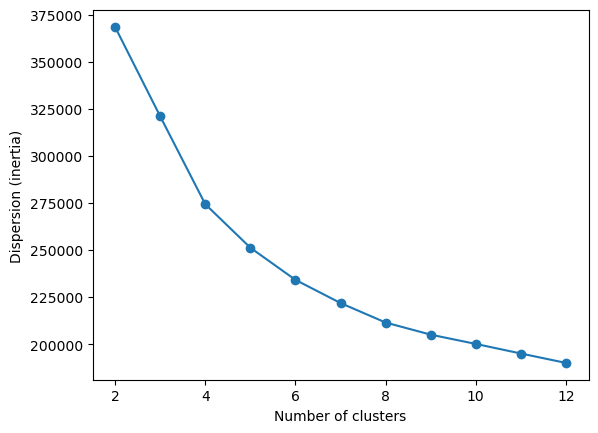

In [7]:
kmeans_workflow.find_optimal_k(X_scaled, K_range=12)

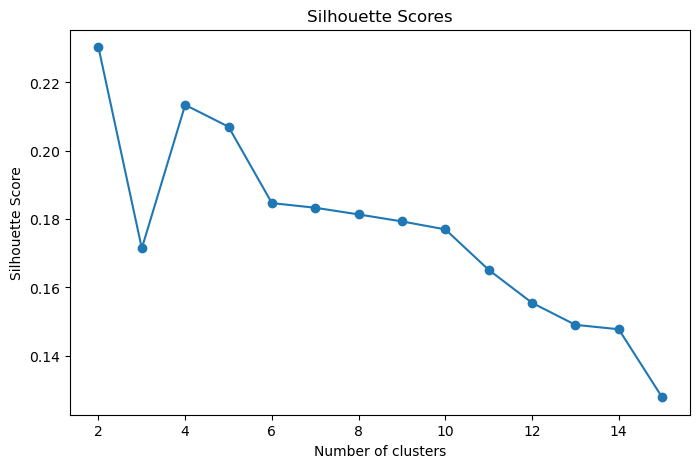

In [8]:
kmeans_workflow.silhouette(X_scaled, K_range=15)

In [15]:
kmeans = KMeans(n_clusters= 7,random_state=42, n_init=10)

kmeans_workflow = Clusteringworkflow(kmeans)
kmeans_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()


,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,lifetime_spend_fish,lifetime_spend_electronics,lifetime_spend_videogames,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_hygiene,lifetime_spend_petfood,latitude,longitude,cluster_kmeans
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,213.0,4553.0,256.0,323.0,177.0,552.0,384.0,38.794428,-9.215739,6
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,15.0,963.0,333.0,533.0,95.0,1880.0,665.0,38.751711,-9.179611,4
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,273.0,0.0,101.0,101.0,118.0,507.0,222.0,38.780678,-9.160656,1
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,1083.0,1105.0,1656.0,757.0,1133.0,485.0,184.0,38.739548,-9.148679,0
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,1015.0,10841.0,1258.0,592.0,718.0,297.0,441.0,38.733071,-9.188188,0


In [16]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
1    8076
6    7101
2    4175
5    3717
4    3302
0    3194
3    2677
Name: count, dtype: int64

In [17]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [18]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6
customer_age,56.864746,56.325904,58.822036,57.644378,57.159297,57.662900,47.263766
kids_home,0.240451,0.788509,1.065389,3.297348,1.049970,1.037127,0.993522
teens_home,0.311522,0.754829,0.930778,2.689204,0.867353,0.901264,0.507675
percentage_of_products_bought_promotion,0.252521,0.188159,0.406442,0.203925,0.156665,0.105995,0.693339
lifetime_spend_groceries,8395.024421,15195.367756,34008.143234,24638.107210,12162.440339,10648.224374,11153.400225
lifetime_spend_vegetables,168.728867,481.300520,360.200000,813.587598,1467.767717,1996.397094,365.159555
lifetime_spend_meat,896.427364,729.281204,1036.875928,1488.307807,162.548758,72.213882,646.895789
lifetime_spend_fish,840.323419,611.290862,976.389461,1302.550616,116.524833,86.228679,384.832700
lifetime_spend_electronics,9890.207577,1199.735884,3282.849581,4935.928651,828.647486,1952.924132,925.732714
lifetime_spend_videogames,1524.405761,199.687593,313.282395,392.562570,148.134767,227.445252,202.541191


In [12]:
numeric_cols = dataset.select_dtypes(include='number').columns.drop('cluster_kmeans')

dataset.groupby("cluster_kmeans")[numeric_cols].mean().T

cluster_kmeans,0,1,2,3
customer_age,56.521222,57.994771,53.264709,57.704261
kids_home,0.454780,1.029739,0.930501,3.286430
teens_home,0.456367,0.876307,0.695046,2.730039
total_children,0.911146,1.906046,1.625547,6.016470
has_children,0.581714,0.970588,0.874234,1.000000
year_first_transaction,2016.265768,2015.500000,2014.918690,2013.045113
distinct_stores_visited,2.285601,3.401144,3.329342,3.118869
number_complaints,1.023007,0.683824,0.955818,0.996778
typical_hour,16.047203,12.288399,12.256343,10.389187
hour_sin,-0.333824,0.042625,0.102917,0.373351


In [13]:
experimental_hierarchical = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage="ward")

hierarchical_workflow = Clusteringworkflow(experimental_hierarchical)

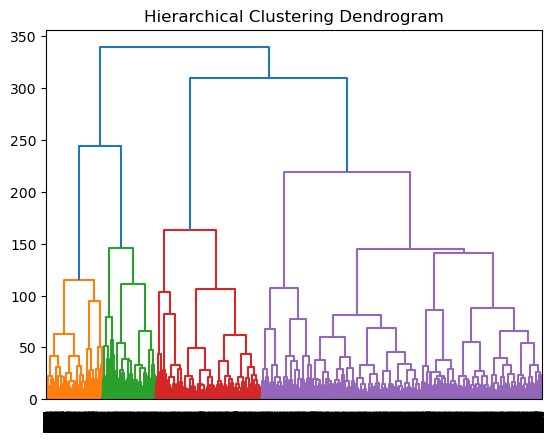

In [14]:
hierarchical_workflow.find_optimal_k(X_scaled)

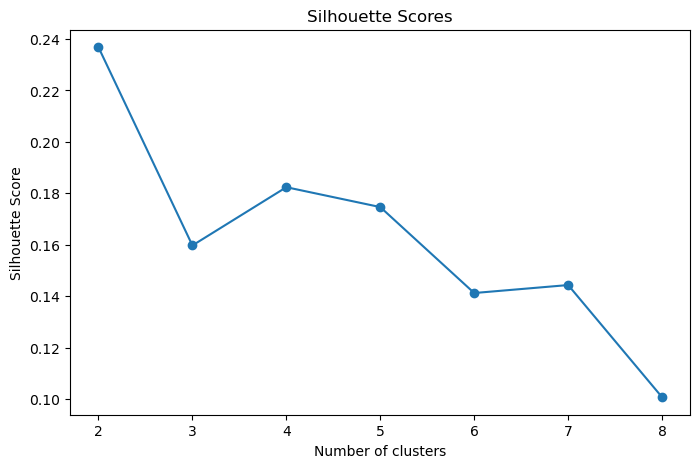

In [15]:
hierarchical_workflow.silhouette(X_scaled, K_range=8)

In [16]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(hierarchical)

hierarchical_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,cluster_kmeans,cluster_agglomerativeclustering
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656,2,0
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867,1,2
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277,2,0
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306,0,3
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095,0,3


In [17]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'has_children',
       'year_first_transaction', 'distinct_stores_visited',
       'number_complaints', 'typical_hour', 'time_of_day', 'hour_sin',
       'hour_cos', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'latitude', 'longitude',
       'share_groceries', 'share_electronics', 'share_vegetables',
       'share_nonalcohol_drinks', 'share_alcohol_drinks', 'share_meat',
       'share_fish', 'share_hygiene', 'share_videogames', 'share_petfood',
       'cluster_kmeans', 'cluster_agglomerativ

In [18]:
pd.DataFrame(
    confusion_matrix(
        dataset['cluster_kmeans'],
        dataset['cluster_agglomerativeclustering']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 4)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 4)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster
K-Means 0 Cluster,282,1525,2,3233
K-Means 1 Cluster,44,258,5680,138
K-Means 2 Cluster,15400,1376,1199,313
K-Means 3 Cluster,2519,262,10,2


In [19]:
pca = PCA(n_components=2, random_state=42)

pca_workflow = PCAWorkflow(pca)
pca_workflow.fit_and_transformation(X_scaled)

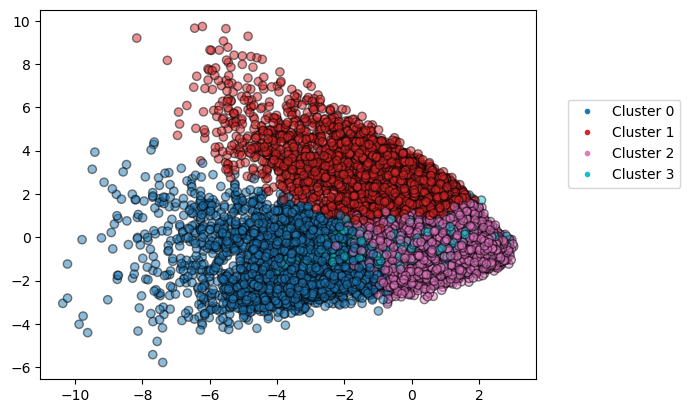

In [20]:
pca_workflow.plot(dataset["cluster_kmeans"])

In [21]:
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_workflow = TSNEWorkflow(tsne)
tsne_workflow.fit_and_transformation(X_scaled)

c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:84: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


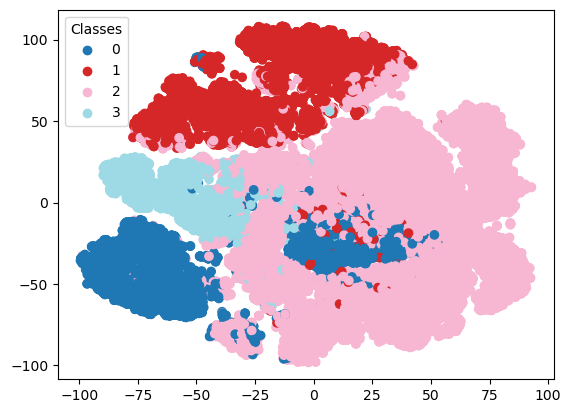

In [22]:
tsne_workflow.plot(dataset["cluster_kmeans"])

In [23]:
umap = UMAP(n_neighbors=15, min_dist=0.3, random_state=42)


umap_workflow = UMAPWorkflow(umap)
umap_workflow.fit_and_transformation(X_scaled)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:84: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


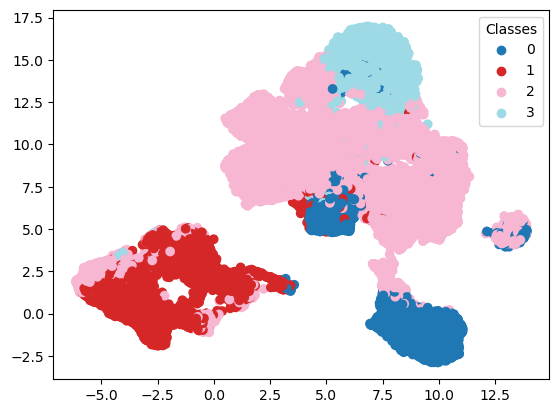

In [24]:
umap_workflow.plot(dataset["cluster_kmeans"])